In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('../data/cse30grades.csv')
print(df.head())

           ID  Homework: Fundamentals (690331)  Homework: Recursion (711087)  \
0  Full Score                               40                            40   
1           1                               40                            50   
2           2                               40                            50   
3           3                               40                            50   
4           4                               40                            50   

   Homework: Generators (712610)  Homework: Classes (713464)  \
0                             50                          40   
1                             60                          40   
2                              0                          32   
3                             60                          40   
4                             50                          40   

   Homework: Classes and Lists (714905)  Homework: Composition (715374)  \
0                                    35                    

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 15 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   ID                                                                  121 non-null    object 
 1   Homework: Fundamentals (690331)                                     121 non-null    int64  
 2   Homework: Recursion (711087)                                        121 non-null    int64  
 3   Homework: Generators (712610)                                       121 non-null    int64  
 4   Homework: Classes (713464)                                          121 non-null    int64  
 5   Homework: Classes and Lists (714905)                                121 non-null    int64  
 6   Homework: Composition (715374)                                      121 non-null    int64  
 7   Homework: Stacks 

In [27]:
#Only missing value was a single "null" final exam grade
df["Final Exam"] = df["Final Exam"].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 15 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   ID                                                                  121 non-null    object 
 1   Homework: Fundamentals (690331)                                     121 non-null    int64  
 2   Homework: Recursion (711087)                                        121 non-null    int64  
 3   Homework: Generators (712610)                                       121 non-null    int64  
 4   Homework: Classes (713464)                                          121 non-null    int64  
 5   Homework: Classes and Lists (714905)                                121 non-null    int64  
 6   Homework: Composition (715374)                                      121 non-null    int64  
 7   Homework: Stacks 

In [28]:
# Converting data to percentage based on full score
full_scores = df.iloc[0]
students = df.iloc[1:].copy()
for col in df.columns:
    if col != 'ID':
        students[col] = (students[col] / full_scores[col]) * 100

students.to_csv('percent.csv', index=False)
students

,ID,Homework: Fundamentals (690331),Homework: Recursion (711087),Homework: Generators (712610),Homework: Classes (713464),Homework: Classes and Lists (714905),Homework: Composition (715374),Homework: Stacks and Queues (690337),Midterm,Homework: Mathematical Expressions (690340),Homework: Mathematical Expressions as Classes (690334),Homework: Mathematical Expressions with Class Inheritance (690335),Homework: Graphs (690333),Homework: Task Scheduling with Dependencies (690339),Final Exam
1,1,100.0,125.0,120.0,100.0,128.571429,100.0,100.0,109.756098,112.5,100.000000,100.000000,100.0,100.000000,100.000000
2,2,100.0,125.0,0.0,80.0,100.000000,80.0,80.0,44.878049,112.5,80.000000,53.333333,100.0,100.000000,40.540541
3,3,100.0,125.0,120.0,100.0,128.571429,100.0,100.0,67.560976,112.5,100.000000,80.000000,100.0,100.000000,78.378378
4,4,100.0,125.0,100.0,100.0,100.000000,100.0,100.0,51.219512,112.5,100.000000,100.000000,100.0,100.000000,67.567568
5,5,100.0,125.0,100.0,100.0,45.714286,0.0,60.0,63.414634,37.5,26.666667,0.000000,50.0,33.333333,35.135135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,116,100.0,125.0,120.0,100.0,128.571429,100.0,100.0,104.878049,112.5,100.000000,100.000000,100.0,100.000000,75.675676
117,117,100.0,125.0,120.0,100.0,128.571429,100.0,100.0,43.902439,112.5,100.000000,100.000000,100.0,100.000000,45.945946
118,118,100.0,125.0,100.0,87.5,100.000000,100.0,100.0,95.121951,100.0,100.000000,100.000000,100.0,100.000000,91.891892
119,119,100.0,125.0,120.0,100.0,128.571429,100.0,100.0,92.682927,112.5,100.000000,100.000000,100.0,100.000000,81.081081


In [29]:
# Temporal Aggregationstudents =students['ID'] != 'Full Score']
students['hw_avg_midterm'] = students[['Homework: Fundamentals (690331)', 'Homework: Recursion (711087)', 'Homework: Generators (712610)', 
                           'Homework: Classes (713464)', 'Homework: Classes and Lists (714905)', 'Homework: Composition (715374)',
                           'Homework: Stacks and Queues (690337)']].mean(axis=1)
students['gap_midterm'] = students['hw_avg_midterm'] - students['Midterm']

students['hw_avg_final'] = students[['Homework: Mathematical Expressions (690340)', 'Homework: Mathematical Expressions as Classes (690334)',
                           'Homework: Mathematical Expressions with Class Inheritance (690335)', 'Homework: Graphs (690333)', 
                          'Homework: Task Scheduling with Dependencies (690339)']].mean(axis=1)

students['gap_final'] = students['hw_avg_final'] - students['Final Exam']

students[['ID', 'hw_avg_midterm', 'Midterm', 'gap_midterm']]


,ID,hw_avg_midterm,Midterm,gap_midterm
1,1,110.510204,109.756098,0.754107
2,2,80.714286,44.878049,35.836237
3,3,110.510204,67.560976,42.949228
4,4,103.571429,51.219512,52.351916
5,5,75.816327,63.414634,12.401692
...,...,...,...,...
116,116,110.510204,104.878049,5.632155
117,117,110.510204,43.902439,66.607765
118,118,101.785714,95.121951,6.663763
119,119,110.510204,92.682927,17.827277


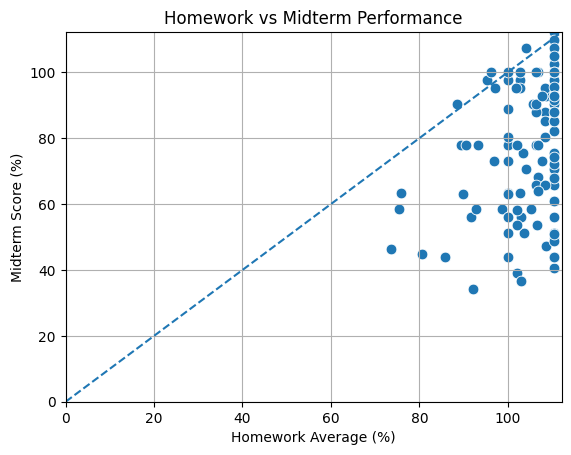

In [77]:
# Phase 2: Exploratory Data Analysis (Visualization) - Midterm
midterm = sns.scatterplot(data=students,x='hw_avg_midterm', y = 'Midterm', s = 60)

midterm_max_val = max(students['hw_avg_midterm'].max(),
              students['Midterm'].max())

plt.xlim(0, midterm_max_val)
plt.ylim(0, midterm_max_val)

# # Add diagonal reference line (y = x)
plt.plot([0, midterm_max_val], [0, midterm_max_val], linestyle='--')

plt.xlabel('Homework Average (%)')
plt.ylabel('Midterm Score (%)')
plt.title('Homework vs Midterm Performance')

plt.grid(True)
plt.show()

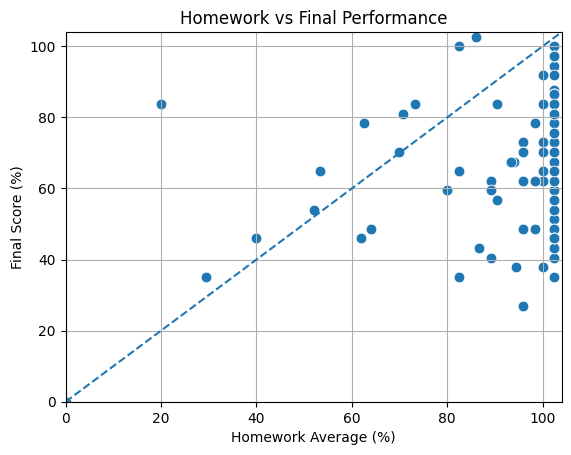

In [ ]:
# Phase 2: Exploratory Data Analysis (Visualization) - Final
final = sns.scatterplot(data=students,x='hw_avg_final', y = 'Final Exam', s = 60)

plt.xlim(0, 104)
plt.ylim(0, 104)

# # Add diagonal reference line (y = x)
plt.plot([0, 130], [0, 130], linestyle='--')

plt.xlabel('Homework Average (%)')
plt.ylabel('Final Score (%)')
plt.title('Homework vs Final Performance')

plt.grid(True)
plt.show()